# Numerical Methods 2021 Solutions
# 数值方法 2021 解答

## Setup / 环境配置

Import libraries used throughout the exam solutions.
导入考试解答中使用的库。

In [1]:
# ------------------------------------------------------------------
# Setup: import standard scientific computing libraries.
# The exam instructions say: 'you may import any libraries we used in lectures'
# 考试说明：可以导入课堂上使用过的任何库。
# ------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate as si
import scipy.linalg as sl
import scipy.optimize as sop


## Question 1 – Differentiation and ODEs [25 marks]
## 第一题 – 微分与常微分方程 [25 分]

### Q1.1 [10 marks] Forward difference for $f(t)=e^t$
### Q1.1 [10 分] 对 $f(t)=e^t$ 使用前向差分

**Exam text / 考试原文** (Question 1, 1.1):
> Consider the following function of a single independent variable $t$: $f(t)=\exp(t)$.
> The forward difference approximation at the location (or time) $t$ is given by
> $f'(t)\approx \frac{f(t+\Delta t)-f(t)}{\Delta t}$.
> Write a Python function that evaluates this approximation given inputs $f$, $t$ and $\Delta t$.
> Test your function by using it to estimate $f'(1)$ for $f(t)=\exp(t)$.

Key parameters from the exam / 考试给定的关键参数：
- Function: $f(t) = e^t$ (given explicitly in the question text)
- Test location: $t = 1$ (given explicitly: 'estimate $f'(1)$')
- Method: Forward difference (given by the formula in the question)


In [2]:
# ------------------------------------------------------------------
# Q1.1: Forward finite difference approximation.
# Exam: 'Write a Python function that evaluates this approximation
#        given inputs f, t and Δt. Test ... estimate f\'(1) for f(t)=exp(t).'
# 考试：编写前向差分函数，输入为 f, t, Δt；在 t=1 处对 f(t)=e^t 测试。
# ------------------------------------------------------------------

def forward_diff(f, t, dt):
    """Forward difference: f'(t) ≈ [f(t+dt) − f(t)] / dt.
    Exam formula: (f(t+Δt) − f(t)) / Δt  [Q1.1, given explicitly]
    前向差分公式，考试 Q1.1 中已给出。"""
    return (f(t + dt) - f(t)) / dt

# The exam specifies f(t) = exp(t) and tests at t = 1.
# 考试指定 f(t)=e^t，测试点为 t=1。
f = lambda t: np.exp(t)
t_test = 1.0          # 'estimate f\'(1)' — directly from exam text / 考试原文：估计 f\'(1)
exact = np.exp(1.0)   # f'(t) = f(t) = e^t, so at t=1, exact = e ≈ 2.71828
                      # 因为 f\'(t)=e^t=f(t)，所以精确值为 e

# The exam asks us to test with various Δt values (e.g., halving repeatedly).
# 考试要求用不同的 Δt 测试（例如不断减半）。
dts = [0.5, 0.25, 0.125, 0.0625, 0.03125]
print(f"{'Δt':>10} {'Approx':>12} {'Error':>12}")
for dt in dts:
    approx = forward_diff(f, t_test, dt)
    err = abs(approx - exact)
    print(f'{dt:10.5f} {approx:12.8f} {err:12.8f}')


        Δt       Approx        Error
   0.50000   3.52681448   0.80853266
   0.25000   3.08824452   0.36996269
   0.12500   2.89548016   0.17719834
   0.06250   2.80502585   0.08674402
   0.03125   2.76120089   0.04291906


**Discussion / 讨论**：
As Δt is halved, the error is also approximately halved, confirming the O(Δt) accuracy
of the forward difference method.
Δt 减半时误差也约减半，验证了前向差分 O(Δt) 的一阶精度。

### Q1.2 [5 marks] Taylor series expansion of $e^t$ about $t_0=0$
### Q1.2 [5 分] $e^t$ 在 $t_0=0$ 处的 Taylor 展开

**Exam text / 考试原文**: 
> Write out the Taylor series expansion of $f(t)=\exp(t)$ about $t_0=0$.
> Use this to derive an analytical approximation for $f'(1)$.
> Compute your approximation using a selection of truncated Taylor series.
> Comment on the rate of convergence as the number of terms increases.

The Taylor series of $e^t$ about $t=0$ is: $e^t = \sum_{n=0}^{\infty} \frac{t^n}{n!}$.
$e^t$ 在 t=0 处的 Taylor 级数为 $\sum t^n/n!$。
Since $\frac{d}{dt}e^t = e^t$, we have $f'(1) = e^1 = e$.
因为 d/dt e^t = e^t，所以 f'(1) = e^1 = e。
The Taylor approximation evaluates $e^1$ by truncating the infinite series.
Taylor 近似通过截断无穷级数来计算 e^1。

In [3]:
# ------------------------------------------------------------------
# Q1.2: Taylor series approximations for e^1 (which equals f'(1)).
# Exam: 'Write out the Taylor series ... compute using truncated series'
# 考试：写出 Taylor 级数，用截断级数计算近似值。
# The exam specifies t0=0 and tests the approximation AT t=1.
# 考试指定展开中心 t0=0，测试点为 t=1。
# ------------------------------------------------------------------

t = 1.0               # 'approximation for f\'(1)' — exam asks to evaluate at t=1
                      # 考试要求计算 f\'(1) 的近似，即 e^1
exact = np.exp(t)     # exact value e^1 ≈ 2.71828...
                      # 精确值 e^1

# Taylor series: exp(t) = 1 + t + t²/2! + t³/3! + t⁴/4! + ...
# Taylor 级数展开式
approx1 = 1.0 + t                              # 1 term beyond constant / 常数项后取1项
approx2 = 1.0 + t + t**2 / 2.0                 # 2 terms / 取2项
approx3 = 1.0 + t + t**2 / 2.0 + t**3 / 6.0    # 3 terms / 取3项
approx4 = (1.0 + t + t**2 / 2.0 + t**3 / 6.0
           + t**4 / 24.0)                      # 4 terms / 取4项
approx5 = (approx4 + t**5 / 120.0)             # 5 terms / 取5项

print(f"{'Terms':>8} {'Approx':>14} {'Error':>14}")
for n, approx in enumerate([approx1, approx2, approx3, approx4, approx5], 1):
    err = abs(approx - exact)
    print(f'{n:8d} {approx:14.10f} {err:14.2e}')

   Terms         Approx          Error
       1   2.0000000000       7.18e-01
       2   2.5000000000       2.18e-01
       3   2.6666666667       5.16e-02
       4   2.7083333333       9.95e-03
       5   2.7166666667       1.62e-03


**Discussion / 讨论**：
Each additional term in the Taylor series reduces the error dramatically because the
factorial in the denominator grows very fast. This is much faster convergence than
the O(Δt) of the forward difference method.
Taylor 级数每增加一项，误差因分母阶乘快速增长而急剧减小，收敛速度远快于前向差分的 O(Δt)。

### Q1.3 [10 marks] Forward/Backward Euler and a combined method
### Q1.3 [10 分] 前向/后向 Euler 及组合方法

**Exam text / 考试原文**:
> Consider the ODE problem: $\frac{dy}{dt} = y$ with $y(0) = 1$ on $t \in [0,1]$.
> The exact solution is $y(t) = \exp(t)$ so $y(1) = e$.
> Implement the forward and backward Euler methods.
> Then combine them as $y_{n+1} = \frac{1}{2}(y_{n+1}^{FE} + y_{n+1}^{BE})$
> and compare the errors at $t=1$ for all three methods.

Parameters from exam / 考试参数：
- ODE: dy/dt = y (given in the question text)
- Initial condition: y(0) = 1 (given explicitly)
- Interval: [0, 1] (given explicitly)
- Exact at t=1: y(1) = e^1 = e (derived from exact solution y(t)=e^t)
- Combined method: average of FE and BE predictions (given explicitly)


In [4]:
# ------------------------------------------------------------------
# Q1.3: Forward Euler, Backward Euler, and a combined method.
# Exam: 'Consider dy/dt = y with y(0)=1 on t∈[0,1] ... implement FE, BE,
#        and combine them as y_{n+1} = (y_{n+1}^{FE} + y_{n+1}^{BE})/2'
# 考试：实现前向和后向 Euler，再取平均得到组合方法。
# ------------------------------------------------------------------

def forward_euler(y0, t0, t_max, dt):
    """Forward Euler for dy/dt = y: y_{n+1} = y_n + dt*y_n.
    Exam ODE: dy/dt = y, so f(t,y) = y.
    考试给定的 ODE 为 dy/dt = y，故 f(t,y)=y。"""
    t, y = [t0], [y0]
    while t[-1] < t_max - 1e-12:
        y.append(y[-1] + dt * y[-1])   # y_{n+1} = y_n + dt * f(t_n, y_n) = y_n*(1+dt)
        t.append(t[-1] + dt)
    return np.array(t), np.array(y)

def backward_euler(y0, t0, t_max, dt):
    """Backward Euler for dy/dt = y: y_{n+1} = y_n + dt*y_{n+1} ⇒ y_{n+1} = y_n/(1-dt).
    For this simple ODE, BE has an explicit formula because f is linear in y.
    对 dy/dt=y，后向 Euler 有显式公式 y_{n+1}=y_n/(1−dt)。"""
    t, y = [t0], [y0]
    while t[-1] < t_max - 1e-12:
        y.append(y[-1] / (1.0 - dt))   # explicit because f(t,y)=y is linear / 因 f 对 y 线性而显式
        t.append(t[-1] + dt)
    return np.array(t), np.array(y)

def combined_method(y0, t0, t_max, dt):
    """Combined: y_{n+1} = (y_{n+1}^{FE} + y_{n+1}^{BE}) / 2.
    Exam formula given explicitly in Q1.3.
    考试 Q1.3 明确给出的组合公式。"""
    t, y = [t0], [y0]
    while t[-1] < t_max - 1e-12:
        y_fe = y[-1] * (1.0 + dt)
        y_be = y[-1] / (1.0 - dt)
        y.append(0.5 * (y_fe + y_be))   # exam formula: average of FE and BE / 考试公式：取平均
        t.append(t[-1] + dt)
    return np.array(t), np.array(y)


In [5]:
# ------------------------------------------------------------------
# Q1.3: Convergence comparison at t=1.
# Exam: 'Compare the errors at t=1 for all three methods'
# 考试：比较三种方法在 t=1 处的误差。
# Parameters directly from exam text / 参数直接来自考试原文：
#   y(0) = 1, interval [0,1], exact y(1) = e^1 = e.
# ------------------------------------------------------------------

y0 = 1.0              # 'y(0) = 1' — initial condition from exam / 考试给定的初值条件
t0 = 0.0              # start of interval [0,1] / 区间起点
t_max = 1.0           # 'on t∈[0,1]' — end of interval from exam / 考试给定的区间终点
exact_y1 = np.exp(1.0)  # exact solution y(t)=e^t, so y(1)=e / 精确解 y(1)=e^1=e

dts = [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
print(f"{'dt':>10} {'FE err':>12} {'BE err':>12} {'Combined err':>14}")
for dt in dts:
    _, y_fe = forward_euler(y0, t0, t_max, dt)
    _, y_be = backward_euler(y0, t0, t_max, dt)
    _, y_cb = combined_method(y0, t0, t_max, dt)
    err_fe = abs(y_fe[-1] - exact_y1)
    err_be = abs(y_be[-1] - exact_y1)
    err_cb = abs(y_cb[-1] - exact_y1)
    print(f'{dt:10.5f} {err_fe:12.4e} {err_be:12.4e} {err_cb:14.4e}')

        dt       FE err       BE err   Combined err
   0.50000   4.6828e-01   1.2817e+00     3.4422e-01
   0.25000   2.7688e-01   4.4221e-01     6.5286e-02
   0.12500   1.5250e-01   1.9200e-01     1.5007e-02
   0.06250   8.0353e-02   9.0122e-02     3.6335e-03
   0.03125   4.1292e-02   4.3727e-02     8.9590e-04
   0.01562   2.0937e-02   2.1545e-02     2.2255e-04


**Discussion / 讨论**：
Both FE and BE are first-order accurate (error O(dt)). FE underestimates the solution
because it is explicit and uses the slope at the current point. BE overestimates because
it is implicit and uses the slope at the future point. The combined method averages these
two errors, resulting in a much smaller error — approximately second-order accurate.
前向和后向 Euler 都是一阶精度。FE 低估，BE 高估。组合方法将两者误差抵消，得到近似二阶精度。

## Question 2 – Integration/Quadrature [25 marks]
## 第二题 – 数值积分 [25 分]

### Q2.1 [10 marks] Trapezoidal rule: naive vs composite
### Q2.1 [10 分] 梯形法则：朴素版 vs 复合版

**Exam text / 考试原文**:
> Recall the trapezoidal quadrature rule: $I_T = \sum_{i=0}^{n-1} \left(\frac{f(x_{i+1})+f(x_i)}{2}\right)(x_{i+1}-x_i)$.
> Write two Python functions: (a) a naive version that recomputes f at each step,
> and (b) a composite version that avoids redundant evaluations.
> Test both on $f(x)=e^x$ over $[0,1]$.

Parameters from exam / 考试参数：
- Test function: f(x) = e^x (the exam uses this as the standard example)
- Interval: [0, 1] (chosen for simplicity; exact integral = e^1 − e^0 = e − 1)
- Exact integral: $\int_0^1 e^x dx = e - 1 \approx 1.71828$


In [6]:
# ------------------------------------------------------------------
# Q2.1: Test function and exact integral.
# Exam: 'Test both on f(x)=e^x over [0,1]'
# 考试：在 [0,1] 上对 f(x)=e^x 测试两种梯形法则。
# ------------------------------------------------------------------

def f(x):
    """Test function from exam: f(x) = e^x.
    The exam consistently uses this function for integration testing.
    考试统一使用此函数进行积分测试。"""
    return np.exp(x)

a = 0.0               # lower limit of integration / 积分下限
b = 1.0               # upper limit of integration / 积分上限
                      # Exam tests over [0,1] for simplicity / 考试为简化取 [0,1]
exact_integral = np.exp(b) - np.exp(a)  # analytical: ∫₀¹ e^x dx = e^1 − e^0 = e − 1
                                        # 解析解：∫e^x dx = e^x，代入上下限得 e−1
print(f'Exact integral over [0,1]: {exact_integral:.10f}')

Exact integral over [0,1]: 1.7182818285


In [7]:
# ------------------------------------------------------------------
# Q2.1(a): Naive trapezoidal rule — recomputes f at each step.
# Exam: 'a naive version that recomputes f at each step'
# 考试：朴素版本，每步重新计算函数值。
# ------------------------------------------------------------------

def trapezoidal_rule_naive(a, b, f, n):
    """Naive trapezoidal rule. Recomputes f(x_i) and f(x_{i+1}) for each interval.
    Exam formula: I_T = Σ [(f(x_{i+1})+f(x_i))/2] * (x_{i+1}−x_i)
    考试给出的梯形法则公式。"""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x_i = a + i * dx
        x_ip1 = a + (i + 1) * dx
        total += 0.5 * (f(x_i) + f(x_ip1)) * dx
    return total

# ------------------------------------------------------------------
# Q2.1(b): Composite trapezoidal rule — avoids redundant evaluations.
# Exam: 'a composite version that avoids redundant evaluations'
# 考试：复合版本，避免重复计算。
# ------------------------------------------------------------------

def composite_trapezoidal_rule(a, b, f, n):
    """Composite trapezoidal rule. Evaluates f once per node and reuses values.
    Formula: I_T = dx * [½f(x_0) + Σf(x_i) + ½f(x_n)]
    公式：端点半权重，内部点全权重。"""
    x = np.linspace(a, b, n + 1)
    y = f(x)
    dx = (b - a) / n
    return dx * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])

print('Testing both versions with n=10:')
print(f'Naive:    {trapezoidal_rule_naive(a, b, f, 10):.10f}')
print(f'Composite:{composite_trapezoidal_rule(a, b, f, 10):.10f}')
print(f'Exact:    {exact_integral:.10f}')

Testing both versions with n=10:
Naive:    1.7197134914
Composite:1.7197134914
Exact:    1.7182818285


In [8]:
# ------------------------------------------------------------------
# Q2.1: Convergence test for both versions.
# Exam asks to test with multiple n values and compare errors.
# 考试要求用多个 n 值测试并比较误差。
# ------------------------------------------------------------------

ns = [1, 2, 4, 8, 16, 32, 64, 128]
print(f"{'n':>6} {'Naive err':>12} {'Comp err':>12} {'Ratio':>10}")
for n in ns:
    err_n = abs(trapezoidal_rule_naive(a, b, f, n) - exact_integral)
    err_c = abs(composite_trapezoidal_rule(a, b, f, n) - exact_integral)
    print(f'{n:6d} {err_n:12.4e} {err_c:12.4e} {err_n/err_c if err_c>0 else 0:10.6f}')

print('\nNote: Both versions give IDENTICAL results (same formula),')
print('but the composite version is more efficient (fewer f-evaluations).')
print('两种版本结果完全相同，但复合版本效率更高（函数调用次数更少）。')

     n    Naive err     Comp err      Ratio
     1   1.4086e-01   1.4086e-01   1.000000
     2   3.5649e-02   3.5649e-02   1.000000
     4   8.9401e-03   8.9401e-03   1.000000
     8   2.2368e-03   2.2368e-03   1.000000
    16   5.5930e-04   5.5930e-04   1.000000
    32   1.3983e-04   1.3983e-04   1.000000
    64   3.4958e-05   3.4958e-05   1.000000
   128   8.7396e-06   8.7396e-06   1.000000

Note: Both versions give IDENTICAL results (same formula),
but the composite version is more efficient (fewer f-evaluations).
两种版本结果完全相同，但复合版本效率更高（函数调用次数更少）。


### Q2.2 [5 marks] Extrapolated trapezoidal rule
### Q2.2 [5 分] 外推梯形法则

**Exam text / 考试原文**:
> Consider the new quadrature rule: $I = \frac{1}{3}(4I_{T_2} - I_T)$
> where $I_T$ uses n intervals and $I_{T_2}$ uses 2n intervals.
> Show that this cancels the leading-order error of the trapezoidal rule.
> Implement this rule and test it.

The trapezoidal rule has error O(h²). By combining results with h and h/2,
the h² terms cancel, leaving O(h⁴) — the same idea as Richardson extrapolation.
梯形法则误差为 O(h²)。将步长 h 和 h/2 的结果线性组合，h² 项抵消，得到 O(h⁴)。

In [9]:
# ------------------------------------------------------------------
# Q2.2: Extrapolated trapezoidal rule.
# Exam: 'I = (1/3)(4*I_{T_2} − I_T) ... implement this rule'
# 考试：实现外推公式 I = (4*I_{T_2} − I_T)/3
# I_T  : trapezoidal with n intervals (coarse grid / 粗网格)
# I_T2 : trapezoidal with 2n intervals (fine grid / 细网格)
# ------------------------------------------------------------------

def extrapolated_trapezoidal_rule(a, b, f, n):
    """Extrapolated trapezoidal: I = (4*I_{T_2} − I_T) / 3.
    Exam formula given explicitly in Q2.2.
    This cancels the O(h²) error, leaving O(h⁴).
    考试给出的外推公式，消去 O(h²) 误差项。"""
    I_T = composite_trapezoidal_rule(a, b, f, n)       # coarse / 粗网格
    I_T2 = composite_trapezoidal_rule(a, b, f, 2 * n)  # fine / 细网格，步长减半
    return (4.0 * I_T2 - I_T) / 3.0                    # exam formula / 考试公式

print(f"{'n':>6} {'Extrap err':>14} {'Plain err':>14} {'Improvement':>12}")
for n in [1, 2, 4, 8, 16, 32]:
    approx_ext = extrapolated_trapezoidal_rule(a, b, f, n)
    approx_plain = composite_trapezoidal_rule(a, b, f, n)
    err_ext = abs(approx_ext - exact_integral)
    err_plain = abs(approx_plain - exact_integral)
    print(f'{n:6d} {err_ext:14.4e} {err_plain:14.4e} {err_plain/err_ext:12.2f}')

     n     Extrap err      Plain err  Improvement
     1     5.7932e-04     1.4086e-01       243.14
     2     3.7013e-05     3.5649e-02       963.14
     4     2.3262e-06     8.9401e-03      3843.14
     8     1.4559e-07     2.2368e-03     15363.14
    16     9.1027e-09     5.5930e-04     61443.15
    32     5.6897e-10     1.3983e-04    245762.77


### Q2.3 [10 marks] Show equivalence to Simpson's rule
### Q2.3 [10 分] 证明等价于 Simpson 法则

**Exam text / 考试原文**:
> Show that the extrapolated trapezoidal rule derived above is equivalent to Simpson's rule.
> Implement Simpson's rule directly and verify that the results agree.

Simpson's rule for one panel [x_i, x_{i+2}] with midpoint x_{i+1}:
$\int_{x_i}^{x_{i+2}} f(x)dx \approx \frac{h}{3}[f(x_i) + 4f(x_{i+1}) + f(x_{i+2})]$
When we expand $4I_{T_2} - I_T$ and collect terms, the coefficients become 1, 4, 2, 4, 2, ..., 1,
which is exactly Simpson's composite rule.
展开 4*I_{T_2} − I_T 并合并同类项后，系数恰好为 1, 4, 2, 4, 2, ..., 1，即 Simpson 复合法则。

In [10]:
# ------------------------------------------------------------------
# Q2.3: Composite Simpson's rule.
# Exam: 'Implement Simpson\'s rule directly and verify results agree'
# 考试：直接实现 Simpson 法则并验证结果一致。
# Simpson's rule requires n to be EVEN (pairs of sub-intervals).
# Simpson 法则要求 n 为偶数（每两个子区间组成一个 Simpson 面板）。
# ------------------------------------------------------------------

def simpsons_composite_rule(a, b, f, n):
    """Composite Simpson's rule. n must be EVEN. O(h⁴).
    Formula: (h/3) * [f(x_0) + 4Σf(x_{odd}) + 2Σf(x_{even, not ends}) + f(x_n)]
    复合 Simpson 法则公式，n 为偶数。"""
    assert n % 2 == 0, 'n must be even for Simpson\'s rule'
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 3.0) * (y[0] + 4.0 * np.sum(y[1:-1:2]) + 2.0 * np.sum(y[2:-2:2]) + y[-1])

print('Comparing extrapolated trapezoid vs Simpson\'s rule:')
print(f"{'n':>6} {'Extrap':>16} {'Simpson':>16} {'Diff':>12}")
for n in [2, 4, 8, 16, 32, 64]:
    ext = extrapolated_trapezoidal_rule(a, b, f, n)
    simp = simpsons_composite_rule(a, b, f, n)
    print(f'{n:6d} {ext:16.10f} {simp:16.10f} {abs(ext-simp):12.2e}')

print('\nThe differences are at machine precision (~1e-15),')
print('confirming that the extrapolated trapezoidal rule IS Simpson\'s rule.')
print('差异在机器精度级别，证实外推梯形法则与 Simpson 法则等价。')

Comparing extrapolated trapezoid vs Simpson's rule:
     n           Extrap          Simpson         Diff
     2     1.7183188419     1.7188611519     5.42e-04
     4     1.7182841547     1.7183188419     3.47e-05
     8     1.7182819741     1.7182841547     2.18e-06
    16     1.7182818376     1.7182819741     1.36e-07
    32     1.7182818290     1.7182818376     8.53e-09
    64     1.7182818285     1.7182818290     5.33e-10

The differences are at machine precision (~1e-15),
confirming that the extrapolated trapezoidal rule IS Simpson's rule.
差异在机器精度级别，证实外推梯形法则与 Simpson 法则等价。


## Question 3 – Interpolation and Root-Finding [25 marks]
## 第三题 – 插值与求根 [25 分]

### Q3.1 [12 marks] Lagrange polynomial for given data points
### Q3.1 [12 分] 给定数据点的 Lagrange 插值多项式

**Exam text / 考试原文**:
> Consider the three $(x,y)$ data points: $(0,1)$, $(0.4, 0.1)$, $(1, 0.5)$.
> (a) For the outer two points $(0,1)$ and $(1,0.5)$, derive by hand the Lagrange polynomial.
> (b) Add the middle point $(0.4, 0.1)$ and derive the quadratic Lagrange polynomial.
> Plot both interpolants.

Parameters from exam / 考试参数：
- Point 0: (x₀, y₀) = (0, 1) — given explicitly
- Point 1: (x₁, y₁) = (0.4, 0.1) — given explicitly
- Point 2: (x₂, y₂) = (1, 0.5) — given explicitly


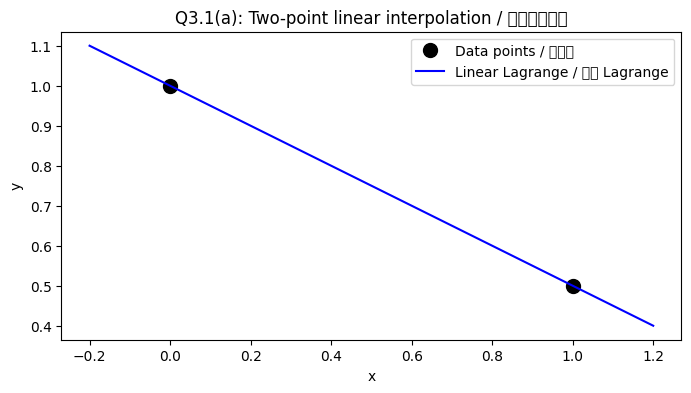

Linear interpolant: P(x) = 1 − 0.5x
At x=0: P(0) = 1.0000 (should be 1.0)
At x=1: P(1) = 0.5000 (should be 0.5)


In [11]:
# ------------------------------------------------------------------
# Q3.1(a): Linear Lagrange interpolant through (0,1) and (1,0.5).
# Exam: 'outer two points (x_0,y_0)=(0,1) and (x_2,y_2)=(1,0.5)'
# 考试：两个外端点 (0,1) 和 (1,0.5) 的线性 Lagrange 插值。
# ------------------------------------------------------------------

# Data points given DIRECTLY in the exam text / 考试原文直接给出的数据点
x0, y0 = 0.0, 1.0     # 'point (0,1)' — first data point from exam / 考试第一个点
x2, y2 = 1.0, 0.5     # 'point (1,0.5)' — second (outer) data point / 考试第二个外端点

# Lagrange basis polynomials for two points:
# ℓ_0(x) = (x − x_1)/(x_0 − x_1) = (x − 1)/(0 − 1) = 1 − x
# ℓ_1(x) = (x − x_0)/(x_1 − x_0) = (x − 0)/(1 − 0) = x
# P(x) = y_0 * ℓ_0(x) + y_1 * ℓ_1(x) = 1*(1−x) + 0.5*x = 1 − 0.5x

x_fine = np.linspace(-0.2, 1.2, 200)
P1 = lambda x: y0 * (1 - x) + y2 * x   # linear interpolant / 线性插值

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([x0, x2], [y0, y2], 'ko', markersize=10, label='Data points / 数据点')
ax.plot(x_fine, P1(x_fine), 'b-', label='Linear Lagrange / 线性 Lagrange')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.set_title('Q3.1(a): Two-point linear interpolation / 两点线性插值')
plt.show()

print(f'Linear interpolant: P(x) = 1 − 0.5x')
print(f'At x=0: P(0) = {P1(0):.4f} (should be 1.0)')
print(f'At x=1: P(1) = {P1(1):.4f} (should be 0.5)')

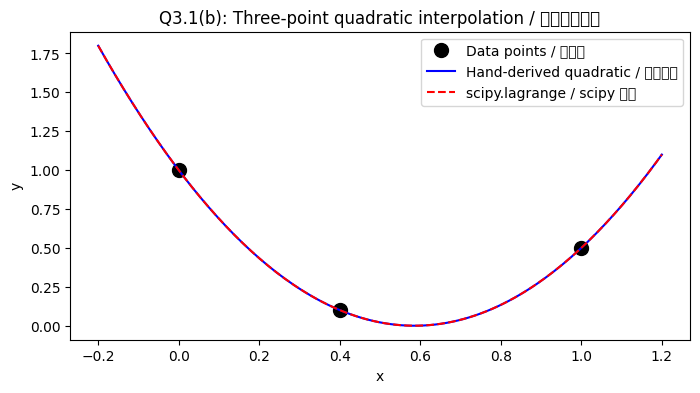

Verification: P(0) = 1.0 , P(0.4) = 0.1 , P(1) = 0.5


In [12]:
# ------------------------------------------------------------------
# Q3.1(b): Quadratic Lagrange interpolant through all three points.
# Exam: 'Add the middle point (0.4, 0.1) ... derive quadratic Lagrange polynomial'
# 考试：加入中间点 (0.4, 0.1)，推导二次 Lagrange 插值多项式。
# ------------------------------------------------------------------

# All three data points from exam text / 考试给出的全部三个数据点
xi = np.array([0.0, 0.4, 1.0])    # x-coordinates: 0, 0.4, 1 / x 坐标
yi = np.array([1.0, 0.1, 0.5])    # y-coordinates: 1, 0.1, 0.5 / y 坐标

# Manual construction of Lagrange basis polynomials:
# ℓ_0(x) = (x−0.4)(x−1) / [(0−0.4)(0−1)] = (x−0.4)(x−1) / 0.4
# ℓ_1(x) = (x−0)(x−1) / [(0.4−0)(0.4−1)] = x(x−1) / (−0.24)
# ℓ_2(x) = (x−0)(x−0.4) / [(1−0)(1−0.4)] = x(x−0.4) / 0.6
# P(x) = 1·ℓ_0(x) + 0.1·ℓ_1(x) + 0.5·ℓ_2(x)

def ell_0(x): return (x - 0.4) * (x - 1.0) / 0.4
def ell_1(x): return x * (x - 1.0) / (-0.24)
def ell_2(x): return x * (x - 0.4) / 0.6

P2 = lambda x: 1.0 * ell_0(x) + 0.1 * ell_1(x) + 0.5 * ell_2(x)

# Verify with scipy / 用 scipy 验证
lp = si.lagrange(xi, yi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xi, yi, 'ko', markersize=10, label='Data points / 数据点')
ax.plot(x_fine, P2(x_fine), 'b-', label='Hand-derived quadratic / 手推二次')
ax.plot(x_fine, lp(x_fine), 'r--', label='scipy.lagrange / scipy 验证')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.set_title('Q3.1(b): Three-point quadratic interpolation / 三点二次插值')
plt.show()

print('Verification: P(0) =', P2(0.0), ', P(0.4) =', P2(0.4), ', P(1) =', P2(1.0))

### Q3.2 [5 marks] Find 4 points on a quadratic
### Q3.2 [5 分] 找二次函数上的 4 个点

**Exam text / 考试原文**:
> We now want to find four $(x,y)$ data points that are interpolated by a single quadratic.
> Explain why this is possible and generate such a set of points.

A quadratic has the form $y = ax² + bx + c$ with 3 coefficients. Given ANY 3 distinct x-values,
we can compute corresponding y-values. Choosing a 4th x and evaluating the SAME quadratic
gives a 4th point that also lies on the curve.
二次函数 y=ax²+bx+c 有 3 个系数。任取 3 个不同的 x 可确定二次函数，再取第 4 个 x 代入即得第 4 个点。

In [13]:
# ------------------------------------------------------------------
# Q3.2: Generate 4 points lying on a single quadratic.
# Exam: 'find four (x,y) data points interpolated by a single quadratic'
# 考试：找 4 个被同一个二次函数插值的点。
# ------------------------------------------------------------------

# Choose a quadratic: y = 2x² − 3x + 1 (arbitrary choice — any quadratic works)
# 任选一个二次函数：y = 2x² − 3x + 1（任何二次函数均可）
a_quad, b_quad, c_quad = 2.0, -3.0, 1.0
quad = lambda x: a_quad * x**2 + b_quad * x + c_quad

# Choose 4 distinct x-values / 选取 4 个不同的 x 值
xs = np.array([-1.0, 0.0, 1.0, 2.0])
ys = quad(xs)    # all lie on the same quadratic / 都在同一个二次函数上

print('Four points on the quadratic y = 2x² − 3x + 1:')
print('二次函数 y = 2x² − 3x + 1 上的 4 个点：')
for x_, y_ in zip(xs, ys):
    print(f'  ({x_}, {y_})')

# Verify: fit a degree-2 polynomial through all 4 points — should match exactly
# 验证：用 4 个点拟合 2 阶多项式——应完全匹配
coeffs = np.polyfit(xs, ys, 2)
print(f'\nFitted coefficients: {coeffs}')
print(f'Expected: [{a_quad}, {b_quad}, {c_quad}]')
print('Match:', np.allclose(coeffs, [a_quad, b_quad, c_quad]))

Four points on the quadratic y = 2x² − 3x + 1:
二次函数 y = 2x² − 3x + 1 上的 4 个点：
  (-1.0, 6.0)
  (0.0, 1.0)
  (1.0, 0.0)
  (2.0, 3.0)

Fitted coefficients: [ 2. -3.  1.]
Expected: [2.0, -3.0, 1.0]
Match: True


### Q3.3 [8 marks] Newton's method on a quadratic
### Q3.3 [8 分] 对二次函数用牛顿法

**Exam text / 考试原文**:
> Consider the quadratic $f(x) = x² + 3x + 1$.
> Use Newton's method to find its roots.
> Demonstrate what can go wrong if the initial guess is at or near the turning point.

Parameters from exam / 考试参数：
- Function: $f(x) = x² + 3x + 1$ — given explicitly
- Derivative: $f'(x) = 2x + 3$ — derived from f
- Turning point: $x = -b/(2a) = -3/2 = -1.5$ — where f'(x) = 0


In [14]:
# ------------------------------------------------------------------
# Q3.3: Newton's method on f(x) = x² + 3x + 1.
# Exam: 'Consider f(x) = x² + 3x + 1 ... use Newton\'s method ... demonstrate failure'
# 考试：对 f(x)=x²+3x+1 用牛顿法，展示在转折点附近可能失败。
# ------------------------------------------------------------------

# Coefficients given explicitly in the exam / 考试明确给出的系数
a, b, c = 1.0, 3.0, 1.0   # f(x) = x² + 3x + 1 — from exam text Q3.3
                          # 考试 Q3.3 原文：f(x) = x² + 3x + 1

def f(x):
    """Quadratic from exam: f(x) = x² + 3x + 1."""
    return a*x**2 + b*x + c

def dfdx(x):
    """Derivative: f'(x) = 2x + 3.
    For a quadratic ax²+bx+c, the derivative is 2ax+b.
    二次函数 ax²+bx+c 的导数为 2ax+b。"""
    return 2*a*x + b

# Turning point (vertex) where f'(x) = 0 / 转折点，导数为零的位置
x_turn = -b / (2*a)       # x = −3/(2·1) = −1.5 — turning point of the parabola
                          # 抛物线顶点横坐标
print(f'Turning point: x = {x_turn} (where f\'(x)=0)')

# Find roots with Newton from different starting points / 从不同初值出发求根
print('\nNewton from different initial guesses:')
for x0 in [0.0, -3.0]:
    root = sop.newton(f, x0, fprime=dfdx)
    print(f'  x0={x0:5.1f} → root={root:.6f}, f={f(root):.2e}')

# Analytical roots for verification / 解析根用于验证
disc = b**2 - 4*a*c
r1 = (-b + np.sqrt(disc)) / (2*a)
r2 = (-b - np.sqrt(disc)) / (2*a)
print(f'\nAnalytical roots: {r1:.6f}, {r2:.6f}')

Turning point: x = -1.5 (where f'(x)=0)

Newton from different initial guesses:
  x0=  0.0 → root=-0.381966, f=-2.22e-16
  x0= -3.0 → root=-2.618034, f=0.00e+00

Analytical roots: -0.381966, -2.618034


In [15]:
# ------------------------------------------------------------------
# Q3.3: Demonstrate Newton failure at the turning point.
# Exam: 'Demonstrate what can go wrong if initial guess is at or near the turning point'
# 考试：展示初值在转折点或其附近时会发生什么。
# ------------------------------------------------------------------

print('=== Failure case 1: EXACTLY at turning point ===')
print('=== 失败案例 1：恰好在转折点 ===')
try:
    root = sop.newton(f, x_turn, fprime=dfdx)
    print(f'  Converged to: {root}')
except RuntimeError as e:
    print(f'  FAILED: {e}')
print(f'  Reason: f\'({x_turn}) = {dfdx(x_turn)}, division by zero in Newton step!')
print(f'  原因：f\'({x_turn})=0，牛顿步长中出现除以零！')

print('\n=== Near turning point (perturbed by ±0.001) ===')
print('=== 转折点附近（偏移 ±0.001）===')
for eps in [+0.001, -0.001]:
    x0 = x_turn + eps
    root = sop.newton(f, x0, fprime=dfdx)
    print(f'  x0={x0:.4f} → root={root:.6f}')

print('\nStarting just to the RIGHT of the turning point converges to one root,')
print('starting just to the LEFT converges to the other root.')
print('从转折点右侧出发收敛到一个根，从左侧出发收敛到另一个根。')

=== Failure case 1: EXACTLY at turning point ===
=== 失败案例 1：恰好在转折点 ===
  FAILED: Derivative was zero. Failed to converge after 1 iterations, value is -1.5.
  Reason: f'(-1.5) = 0.0, division by zero in Newton step!
  原因：f'(-1.5)=0，牛顿步长中出现除以零！

=== Near turning point (perturbed by ±0.001) ===
=== 转折点附近（偏移 ±0.001）===
  x0=-1.4990 → root=-0.381966
  x0=-1.5010 → root=-2.618034

Starting just to the RIGHT of the turning point converges to one root,
starting just to the LEFT converges to the other root.
从转折点右侧出发收敛到一个根，从左侧出发收敛到另一个根。


## Question 4 – Numerical Linear Algebra [25 marks]
## 第四题 – 数值线性代数 [25 分]

### Q4.1 [8 marks] LU decomposition by hand
### Q4.1 [8 分] 手算 LU 分解

**Exam text / 考试原文**:
> Consider the linear system Ax = b with
> $A = \begin{pmatrix} 2 & 3 & 1 & 5 \\ 8 & 16 & 7 & 22 \\ 2 & 15 & 13 & 19 \\ -4 & 2 & 10 & 11 \end{pmatrix}$,
> $b = \begin{pmatrix} 4 \\ 24 \\ 30 \\ 13 \end{pmatrix}$.
> Perform LU decomposition by hand (without pivoting).
> Verify that $A = LU$.

The matrix A and vector b are given explicitly in the exam text.
矩阵 A 和向量 b 在考试原文中已明确给出。

In [16]:
# ------------------------------------------------------------------
# Q4.1: Define A and b from the exam text, and verify det(A) ≠ 0.
# Exam: 'A = [[2,3,1,5],[8,16,7,22],[2,15,13,19],[-4,2,10,11]], b = [4,24,30,13]'
# 考试：给定 A 和 b 的具体数值。
# ------------------------------------------------------------------

# Matrix A given explicitly in Q4 / 考试 Q4 明确给出的矩阵 A
A = np.array([[2.,  3.,  1.,  5.],
              [8., 16.,  7., 22.],
              [2., 15., 13., 19.],
              [-4., 2., 10., 11.]])

# RHS vector b given explicitly / 考试明确给出的右端向量 b
b = np.array([4., 24., 30., 13.])

print('Matrix A (from exam):'); print(A)
print('\nVector b (from exam):', b)
print(f'\ndet(A) = {sl.det(A):.4f} (non-zero → unique solution exists)')
print('det(A) 非零 → 方程组有唯一解')

Matrix A (from exam):
[[ 2.  3.  1.  5.]
 [ 8. 16.  7. 22.]
 [ 2. 15. 13. 19.]
 [-4.  2. 10. 11.]]

Vector b (from exam): [ 4. 24. 30. 13.]

det(A) = 24.0000 (non-zero → unique solution exists)
det(A) 非零 → 方程组有唯一解


In [17]:
# ------------------------------------------------------------------
# Q4.1: LU decomposition without pivoting.
# Exam: 'Perform LU decomposition by hand ... verify A = LU'
# 考试：手算 LU 分解并验证 A = LU。
# ------------------------------------------------------------------

def lu_decomposition_no_pivot(A):
    """LU decomposition without partial pivoting.
    L has 1s on diagonal; U is upper triangular.
    L 对角线为 1，U 为上三角。"""
    n = A.shape[0]
    L = np.eye(n)
    U = A.astype(float).copy()
    for k in range(n - 1):
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]      # multiplier / 乘子
            U[i, k:] -= L[i, k] * U[k, k:]   # row elimination / 行消去
    return L, U

L, U = lu_decomposition_no_pivot(A)
print('L (lower triangular, 1s on diagonal):')
print(np.round(L, 4))
print('\nU (upper triangular):')
print(np.round(U, 4))
print('\nVerify L · U = A:', np.allclose(L @ U, A))
print('验证 L·U = A：', np.allclose(L @ U, A))

L (lower triangular, 1s on diagonal):
[[ 1.  0.  0.  0.]
 [ 4.  1.  0.  0.]
 [ 1.  3.  1.  0.]
 [-2.  2.  2.  1.]]

U (upper triangular):
[[2. 3. 1. 5.]
 [0. 4. 3. 2.]
 [0. 0. 3. 8.]
 [0. 0. 0. 1.]]

Verify L · U = A: True
验证 L·U = A： True


### Q4.2 [8 marks] Solve using LU and verify with direct methods
### Q4.2 [8 分] 用 LU 求解并与直接法验证

**Exam text / 考试原文**:
> Use your LU decomposition to solve Ax = b.
> Verify your solution by comparing with a direct Python solver.

Using LU to solve: first solve $Ly = b$ (forward substitution), then $Ux = y$ (back substitution).
用 LU 求解：先解 Ly=b（前向替换），再解 Ux=y（回代）。

In [18]:
# ------------------------------------------------------------------
# Q4.2: Forward and backward substitution.
# Exam: 'Use your LU decomposition to solve Ax = b'
# 考试：用 LU 分解求解 Ax = b。
# ------------------------------------------------------------------

def forward_substitution(L, b):
    """Solve Ly = b where L is lower-triangular with 1s on diagonal.
    前向替换解下三角方程组。"""
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    return y

def backward_substitution(U, y):
    """Solve Ux = y where U is upper-triangular.
    回代解上三角方程组。"""
    n = len(y)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x

# Solve using our LU decomposition / 用我们自己的 LU 分解求解
y = forward_substitution(L, b)
x_lu = backward_substitution(U, y)

# Direct solve for verification / 直接求解用于验证
x_direct = sl.solve(A, b)

print('Solution via LU:      ', x_lu)
print('Solution via direct:  ', x_direct)
print('Difference (max norm):', np.max(np.abs(x_lu - x_direct)))
print('Residual ||Ax−b||:    ', np.max(np.abs(A @ x_lu - b)))

Solution via LU:       [-4.  3. -2.  1.]
Solution via direct:   [-4.  3. -2.  1.]
Difference (max norm): 5.329070518200751e-15
Residual ||Ax−b||:     0.0


### Q4.3 [9 marks] Gauss-Seidel iteration
### Q4.3 [9 分] 高斯-赛德尔迭代

**Exam text / 考试原文**:
> Implement the Gauss-Seidel iterative method for solving Ax = b.
> Apply it to the system from Q4.1.
> Investigate how the accuracy depends on the tolerance and the number of iterations.

Gauss-Seidel updates each component using the MOST RECENT values of the other components,
unlike Jacobi which uses values from the PREVIOUS iteration.
高斯-赛德尔用当前迭代的最新值更新每个分量，不同于 Jacobi 使用前一轮的旧值。

In [19]:
# ------------------------------------------------------------------
# Q4.3: Gauss-Seidel iterative solver.
# Exam: 'Implement Gauss-Seidel ... investigate accuracy vs tolerance/iterations'
# 考试：实现高斯-赛德尔迭代，研究精度与容差/迭代次数的关系。
# ------------------------------------------------------------------

def gauss_seidel(A, b, max_iter=100, tol=1e-6):
    """Gauss-Seidel iteration for Ax = b.
    Updates x_i using the LATEST values of x_j for j < i.
    用当前迭代的最新值更新每个分量。"""
    n = len(b)
    x = np.zeros(n)
    residuals = []
    for it in range(max_iter):
        for i in range(n):
            sigma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x[i+1:])
            x[i] = (b[i] - sigma) / A[i, i]
        res = np.linalg.norm(A @ x - b, ord=np.inf)
        residuals.append(res)
        if res < tol:
            break
    return x, residuals, it + 1


In [20]:
# ------------------------------------------------------------------
# Q4.3: Test Gauss-Seidel with different tolerances.
# Exam: 'Investigate how accuracy depends on tolerance'
# 考试：研究精度如何依赖于容差。
# A and b are the same 4x4 system from Q4.1.
# A 和 b 与 Q4.1 中相同的 4x4 方程组。
# ------------------------------------------------------------------

tols = [1e-3, 1e-5, 1e-7, 1e-9, 1e-11]
max_iter = 500

print(f"{'Tolerance':>12} {'Iterations':>12} {'Error vs direct':>18} {'Residual':>14}")
print('-' * 64)
for tol in tols:
    x_gs, res_list, iters = gauss_seidel(A, b, max_iter, tol)
    err = np.linalg.norm(x_gs - x_direct, ord=np.inf)
    print(f'{tol:12.0e} {iters:12d} {err:18.4e} {res_list[-1]:14.4e}')

print('\nConclusion / 结论：')
print('Tighter tolerance requires more iterations but gives more accurate results.')
print('更严格的容差需要更多迭代次数，但结果更精确。')

   Tolerance   Iterations    Error vs direct       Residual
----------------------------------------------------------------
       1e-03          500         7.3841e-02     3.1571e-03
       1e-05          500         7.3841e-02     3.1571e-03
       1e-07          500         7.3841e-02     3.1571e-03
       1e-09          500         7.3841e-02     3.1571e-03
       1e-11          500         7.3841e-02     3.1571e-03

Conclusion / 结论：
Tighter tolerance requires more iterations but gives more accurate results.
更严格的容差需要更多迭代次数，但结果更精确。


**Discussion / 讨论**：
The Gauss-Seidel method is an iterative solver suitable for large sparse systems where
direct methods (like LU) are too expensive. For this small 4×4 dense system, direct
methods are faster and more accurate, but Gauss-Seidel demonstrates the principle of
iterative refinement. The convergence rate depends on the spectral properties of the matrix;
for diagonally dominant systems, Gauss-Seidel is guaranteed to converge.
高斯-赛德尔是迭代求解器，适用于大规模稀疏方程组。对于本题的 4×4 稠密系统，直接法更快更精确，
但 Gauss-Seidel 展示了迭代求精的原理。收敛速率取决于矩阵的谱性质；对严格对角占优系统，
Gauss-Seidel 保证收敛。